In [85]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

In [86]:
np.random.seed(23200252)

### 1. Gere o chirp base $x_0[n]$ para $SF = 8$ e $BW = 125 kHz$ ($M = 256$ amostras).

O chirp base $x_0[n]$ é definido como:
$$x_0[n] = e^{j2\pi\left(\frac{n^2}{2M} - \frac{n}{2}\right)}, \quad n = 0, 1, \ldots, M-1$$

O termo quadrático em $n$ faz a frequência instantânea varrer linearmente de $-BW/2$ até $+BW/2$ ao longo do símbolo. Como o expoente é puramente imaginário, $|x_0[n]| = 1$ para todo $n$. (slide 11)

In [87]:
def gera_chirp_base(SF):
    M = 2 ** SF
    n = np.arange(M)

    chirp_base = np.exp(1j * 2 * np.pi * (n**2 / (2 * M) - n / 2))

    return chirp_base

In [88]:
BW = 125e3
SF = 8
M  = 2 ** SF # 256

In [89]:
x0 = gera_chirp_base(SF)

print(f'SF = {SF}, M = {M}')
print(f'|x0[n]| = 1 para todo n? {np.allclose(np.abs(x0), 1)}')

SF = 8, M = 256
|x0[n]| = 1 para todo n? True


### 2. Transmita o símbolo $m = 100$: gere $x_m[n] = x_0[(n + m) \bmod M]$.

Os símbolos são obtidos por deslocamentos circulares do chirp base:
$$x_m[n] = x_0[(n + m) \bmod M]$$

Deslocar o chirp no tempo equivale a mudar a frequência em que ele começa — esse deslocamento inicial é exatamente o que codifica o símbolo $m$.

In [90]:
def gera_simbolo(x0, m):
    M = len(x0)
    n = np.arange(M)

    simbolo = x0[(n + m) % M]

    return simbolo

In [91]:
m_symbol = 100

In [92]:
xm = gera_simbolo(x0, m_symbol)

print(f'xm[0] == x0[{m_symbol}]? {np.isclose(xm[0], x0[m_symbol])}')

xm[0] == x0[100]? True


### 3. Adicione ruído AWGN complexo com $SNR = 0 \,dB$.

O modelo de recepção do slide 13 assume:
$$y_m[n] = e^{j\psi} x_m[n] + w[n], \quad n = 0, 1, \ldots, M-1$$

onde $w[n]$ são amostras de ruído AWGN complexo $\mathcal{CN}(0, \sigma^2)$, geradas como:
$$w[n] = \sqrt{\frac{\sigma^2}{2}} \cdot \left( \mathcal{N}(0,1) + j\,\mathcal{N}(0,1) \right), \quad \sigma^2 = \frac{\mathbb{E}[|x_m[n]|^2]}{\text{SNR}}$$

O fator $1/2$ divide a potência igualmente entre as componentes I e Q.

In [93]:
def adiciona_ruido_awgn(sinal, snr_db):
    M = len(sinal)
    snr_linear = 10 ** (snr_db / 10)
    pot_ruido  = np.mean(np.abs(sinal) ** 2) / snr_linear

    ruido = np.sqrt(pot_ruido / 2) * (np.random.randn(M) + 1j * np.random.randn(M))
    sinal_ruido = sinal + ruido

    return sinal_ruido

In [94]:
snr_db = 0

In [95]:
ym = adiciona_ruido_awgn(xm, snr_db)
print(f'SNR = {snr_db} dB aplicada. potencia do sinal: {np.mean(np.abs(xm)**2):.4f}, potência do sinal + ruído: {np.mean(np.abs(ym)**2):.4f}')


SNR = 0 dB aplicada. potencia do sinal: 1.0000, potência do sinal + ruído: 2.0216


### 4. Faça o dechirping ($v_m[n] = y_m[n] · x_0^*[n]$) e calcule a $DFT$ de $M$ pontos.

O dechirping é feito multiplicando o sinal recebido pelo conjugado do chirp base (slide 14):
$$v_m[n] = y_m[n] \cdot x_0^*[n]$$

isso transforma $x_m[n]$ numa senóide de frequência discreta $m/M$:
$$v_m[n] = e^{j\psi_m} e^{j2\pi nm/M} + \hat{w}[n]$$

A detecção é feita com uma DFT de $M$ pontos (slide 15/16), que concentra toda a energia no bin $k = m$:
$$V_m[k] = \begin{cases} \sqrt{M} e^{j\psi_m} + W[k], & k = m \\ W[k], & k \neq m \end{cases}$$


In [96]:
def dechirp_dft(ym, x0):
    M = len(x0)

    vm = ym * np.conj(x0)
    Vk = np.abs(np.fft.fft(vm) / np.sqrt(M))

    return Vk

In [97]:
Vk = dechirp_dft(ym, x0)

### 5. Verifique que $argmax_k |V[k]| = m$. Plote $|V[k]|$ vs. $k$.

O decisor não-coerente (slide 17) é simplesmente:
$$\hat{m} = \arg\max_k |V_m[k]|$$

A SNR após dechirping (slide 16) é:
$$\text{SNR}_{\text{pós}} = \frac{M}{N_0} = \frac{2^{\text{SF}}}{N_0}$$

ou seja, um ganho de espalhamento de $10\log_{10}(M)$ dB sobre a SNR de entrada.


In [98]:
k_det = np.argmax(Vk)

correto = 'V correto' if k_det == m_symbol else f'>< erro (k={k_det})'

print(f'Símbolo detectado: k = {k_det}  ->  {correto}')

Símbolo detectado: k = 100  ->  V correto


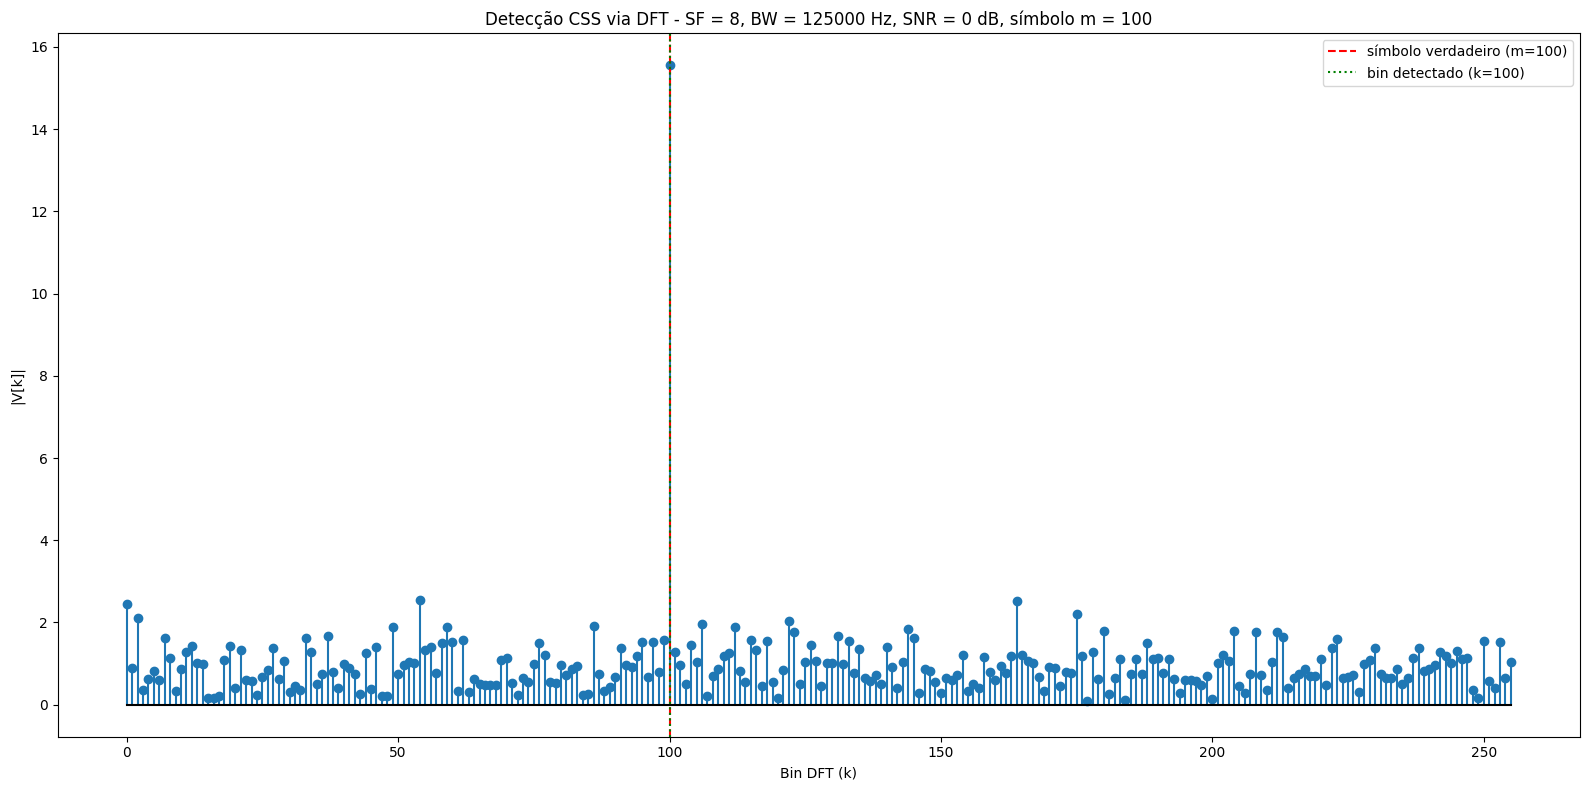

In [99]:
plt.figure(figsize=(16, 8))
plt.stem(np.arange(M), Vk, linefmt='C0-', markerfmt='C0o', basefmt='k-')
plt.axvline(m_symbol, color='red',   linestyle='--', linewidth=1.5, label=f'símbolo verdadeiro (m={m_symbol})')
plt.axvline(k_det,    color='green', linestyle=':',  linewidth=1.5, label=f'bin detectado (k={k_det})')
plt.title(f'Detecção CSS via DFT - SF = {SF}, BW = {int(BW)} Hz, SNR = {snr_db} dB, símbolo m = {m_symbol}')

plt.xlabel('Bin DFT (k)')
plt.ylabel('|V[k]|')
plt.legend()
plt.tight_layout()

plt.show()

### 6. e 7. Variando SNR e SF

In [100]:
def simula_css(SF, snr_db, m_symbol):
    x0 = gera_chirp_base(SF)
    M  = 2 ** SF
    m_eff = m_symbol % M  

    xm = gera_simbolo(x0, m_eff)
    ym = adiciona_ruido_awgn(xm, snr_db)
    Vk = dechirp_dft(ym, x0)
    k_det = np.argmax(Vk)

    return Vk, k_det, m_eff, M

In [101]:
SFs = [7, 8, 9, 10,11, 12]
snrs = [0, -6, -10]

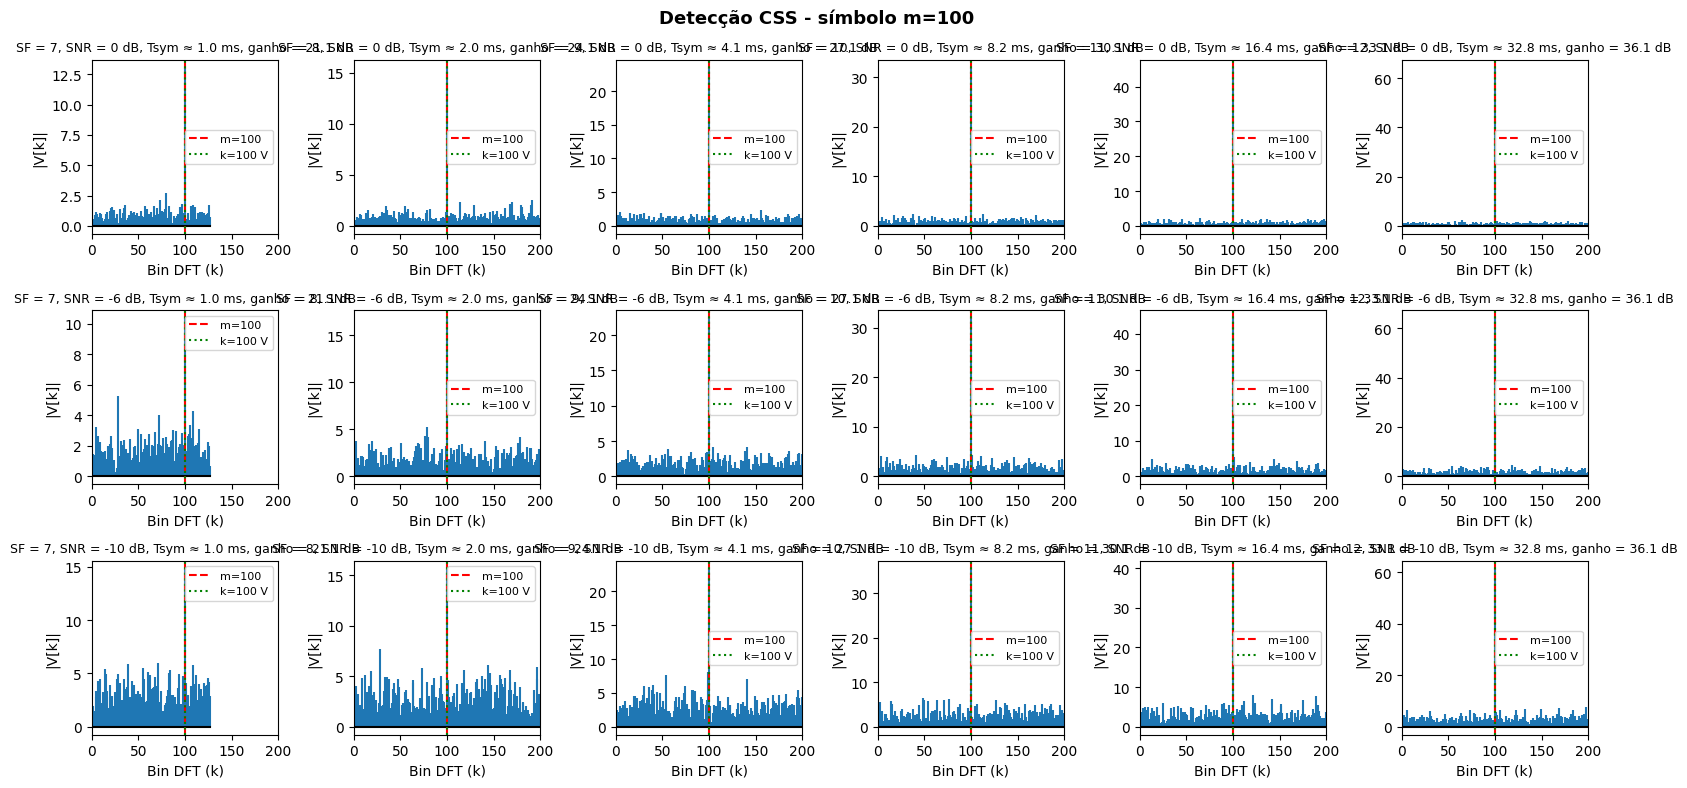

In [102]:
fig, axes = plt.subplots(len(snrs), len(SFs), figsize=(16, 8))
fig.suptitle(f'Detecção CSS - símbolo m={m_symbol}', fontsize=13, fontweight='bold')

for (i, snr), (j, sf) in product(enumerate(snrs), enumerate(SFs)):
    Vk, k_det, m_eff, M = simula_css(sf, snr, m_symbol)
    correto = 'V' if k_det == m_eff else f'>< k = {k_det}'
    Tsym = M / 125e3 * 1e3

    ax = axes[i, j]
    ax.stem(np.arange(M), Vk, linefmt='C0-', markerfmt='', basefmt='k-')
    
    janela = 100
    ax.set_xlim(m_eff - janela, m_eff + janela) # centralizar
    
    ax.axvline(m_eff, color='red',   linestyle='--', linewidth=1.5, label=f'm={m_eff}')
    ax.axvline(k_det, color='green', linestyle=':',  linewidth=1.5, label=f'k={k_det} {correto}')
    ax.set_title(f'SF = {sf}, SNR = {snr} dB, Tsym ≈ {Tsym:.1f} ms, ganho = {10*np.log10(M):.1f} dB', fontsize=9)
    ax.set_xlabel('Bin DFT (k)')
    ax.set_ylabel('|V[k]|')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### 8. Discussão

O primeiro gráfico (SF = 8, SNR = 0 dB) mostra claramente o princípio de detecção CSS: após o dechirping e a DFT, toda a energia do símbolo se concentra no bin k = 100, que se destaca nitidamente acima do ruído de fundo. O símbolo foi detectado corretamente com argmax |V[k]| = m = 100, o que confirma que o receptor não-coerente funciona mesmo a 0 dB de SNR, condição em que o sinal e o ruído têm a mesma potência.

O segundo conjunto de gráficos revela o efeito conjunto da SNR e do Spreading Factor. Quanto à SNR, observa-se que a 0 dB o pico em k = 100 é sempre bem definido independentemente do SF. A −6 dB a detecção continua correta para todos os SFs, mas o ruído já é consideravelmente mais elevado, reduzindo a margem de decisão. A −10 dB o pico ainda é detectável para SFs maiores (a partir de SF = 9/10), mas para SF = 7 o ruído começa a competir com o sinal de forma muito mais preocupante, tornando a detecção menos assertiva.

Quanto ao SF, o efeito é o oposto, quanto maior o SF, maior o M = 2^SF e, consequentemente, maior o ganho de espalhamento. Isso é visível nos gráficos pelo crescimento da amplitude do pico e pela melhor separação sinal/ruído mesmo em SNRs negativas. O custo é o aumento do tempo de símbolo (Tsym = M/BW), que vai de ~1 ms (SF = 7) até ~32,8 ms (SF = 12), reduzindo a taxa de transmissão.